# 07. Frequency Domain Transformation
**Objective:** Transform the raw 200ms time-domain windows into frequency-domain magnitude spectra. This serves as the optimized input for our Dictionary Learning (K-SVD and Mini-Batch) algorithms.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.config import PREPROCESSED_DIR
from src.frequency import extract_fft_magnitude

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Load Preprocessed Time-Domain Windows (Subject 1)

In [2]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y'])
    reps_bal = np.array(f['reps'])

print(f"Original Time-Domain Shape: {X_bal.shape}")

Original Time-Domain Shape: (18630, 20, 10)


### 2. Transform to Frequency Domain

In [3]:
X_freq = extract_fft_magnitude(X_bal)

Extracting FFT from input shape (18630, 20, 10)...
FFT extraction complete. Output shape: (18630, 10, 10)


### 3. Visualize the Transformation
Let's compare the time-domain vs frequency-domain representation of a single active gesture on Channel 1.

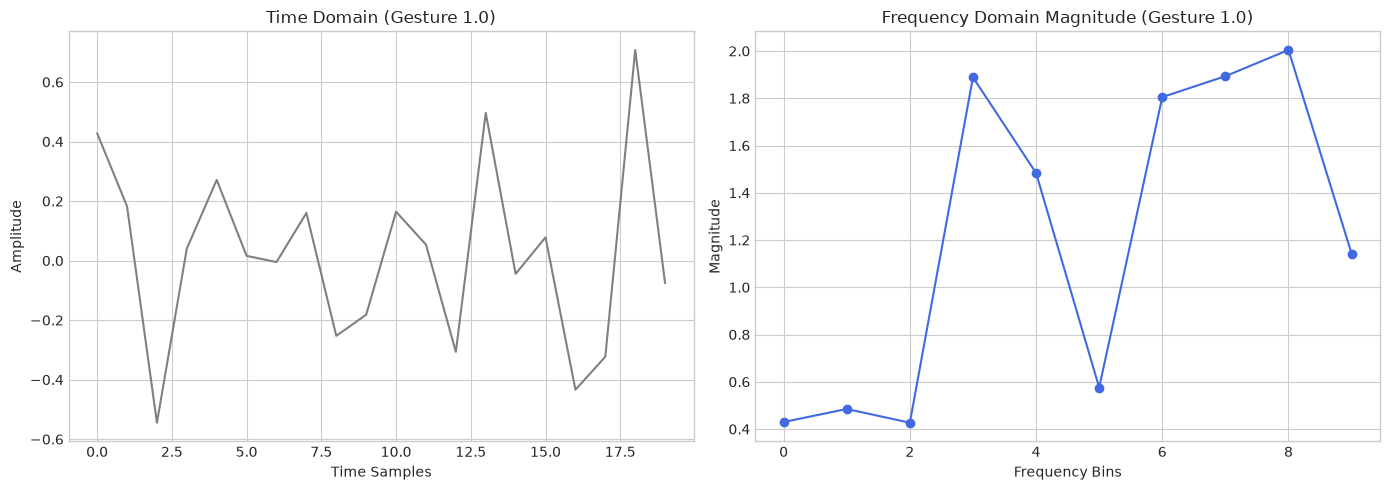

In [4]:
# Find the first active gesture
active_idx = np.where(y_bal > 0)[0][0]

time_signal = X_bal[active_idx, :, 0] # First active window, all samples, Channel 0
freq_signal = X_freq[active_idx, :, 0] # First active window, all frequencies, Channel 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Time Domain
axes[0].plot(time_signal, color='gray')
axes[0].set_title(f"Time Domain (Gesture {y_bal[active_idx]})")
axes[0].set_xlabel("Time Samples")
axes[0].set_ylabel("Amplitude")

# Plot Frequency Domain
axes[1].plot(freq_signal, color='royalblue', marker='o')
axes[1].set_title(f"Frequency Domain Magnitude (Gesture {y_bal[active_idx]})")
axes[1].set_xlabel("Frequency Bins")
axes[1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

### 4. Train K-SVD and Mini-Batch Dictionaries on Frequency Spectra
We learn 32 frequency atoms (n_atoms=32) per channel, enforcing high sparsity (n_nonzero_coefs=3).

In [6]:
from src.dictionary_freq import FrequencyDictionaryLearner, FrequencyOMPExtractor

# Repetition split (Reps 1-7 Train, 8-10 Test)
train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

X_freq_train, y_train = X_freq[train_idx], y_bal[train_idx]
X_freq_test, y_test = X_freq[test_idx], y_bal[test_idx]

print(f"Frequency Training Set: {X_freq_train.shape}")
print(f"Frequency Testing Set: {X_freq_test.shape}")

# 1. Train K-SVD Dictionary
ksvd_learner = FrequencyDictionaryLearner(n_atoms=32, transform_n_nonzero_coefs=3, method='ksvd')
ksvd_learner.fit(X_freq_train)
ksvd_learner.save_dictionary("emg_dict_ksvd_freq_S1.npz")

# 2. Train Mini-Batch Dictionary
mb_learner = FrequencyDictionaryLearner(n_atoms=32, transform_n_nonzero_coefs=3, method='minibatch')
mb_learner.fit(X_freq_train)
mb_learner.save_dictionary("emg_dict_minibatch_freq_S1.npz")

Frequency Training Set: (12664, 10, 10)
Frequency Testing Set: (5444, 10, 10)
Training KSVD Dictionary with 32 atoms on 126640 frequency spectra...


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence

Dictionary learning complete.
Dictionary saved to /workspaces/TCC/models/emg_dict_ksvd_freq_S1.npz
Training MINIBATCH Dictionary with 32 atoms on 126640 frequency spectra...
Dictionary learning complete.
Dictionary saved to /workspaces/TCC/models/emg_dict_minibatch_freq_S1.npz


### 5. Extract Sparse Codes & Compare Feature Spaces
Projecting unseen test frequency spectra onto both learned dictionaries via OMP.

In [7]:
ksvd_extractor = FrequencyOMPExtractor(ksvd_learner.dictionary_, n_nonzero_coefs=3)
mb_extractor = FrequencyOMPExtractor(mb_learner.dictionary_, n_nonzero_coefs=3)

X_test_ksvd_sparse = ksvd_extractor.transform(X_freq_test)
X_test_mb_sparse = mb_extractor.transform(X_freq_test)

print(f"\nK-SVD Sparse Codes Output Shape: {X_test_ksvd_sparse.shape} (Windows x Features)")
print(f"Mini-Batch Sparse Codes Output Shape: {X_test_mb_sparse.shape} (Windows x Features)")

# Calculate Sparsity Percentage
zero_count_ksvd = np.sum(X_test_ksvd_sparse == 0)
total_elements = X_test_ksvd_sparse.size
print(f"K-SVD Feature Matrix Sparsity: {(zero_count_ksvd / total_elements) * 100:.2f}% zero values")

/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)



K-SVD Sparse Codes Output Shape: (5444, 320) (Windows x Features)
Mini-Batch Sparse Codes Output Shape: (5444, 320) (Windows x Features)
K-SVD Feature Matrix Sparsity: 90.63% zero values


### 6. Visualizing Learned Frequency Atoms & Sparse Feature Activation
Plotting a comparison between K-SVD and Mini-Batch frequency atoms and their corresponding sparse activation maps.

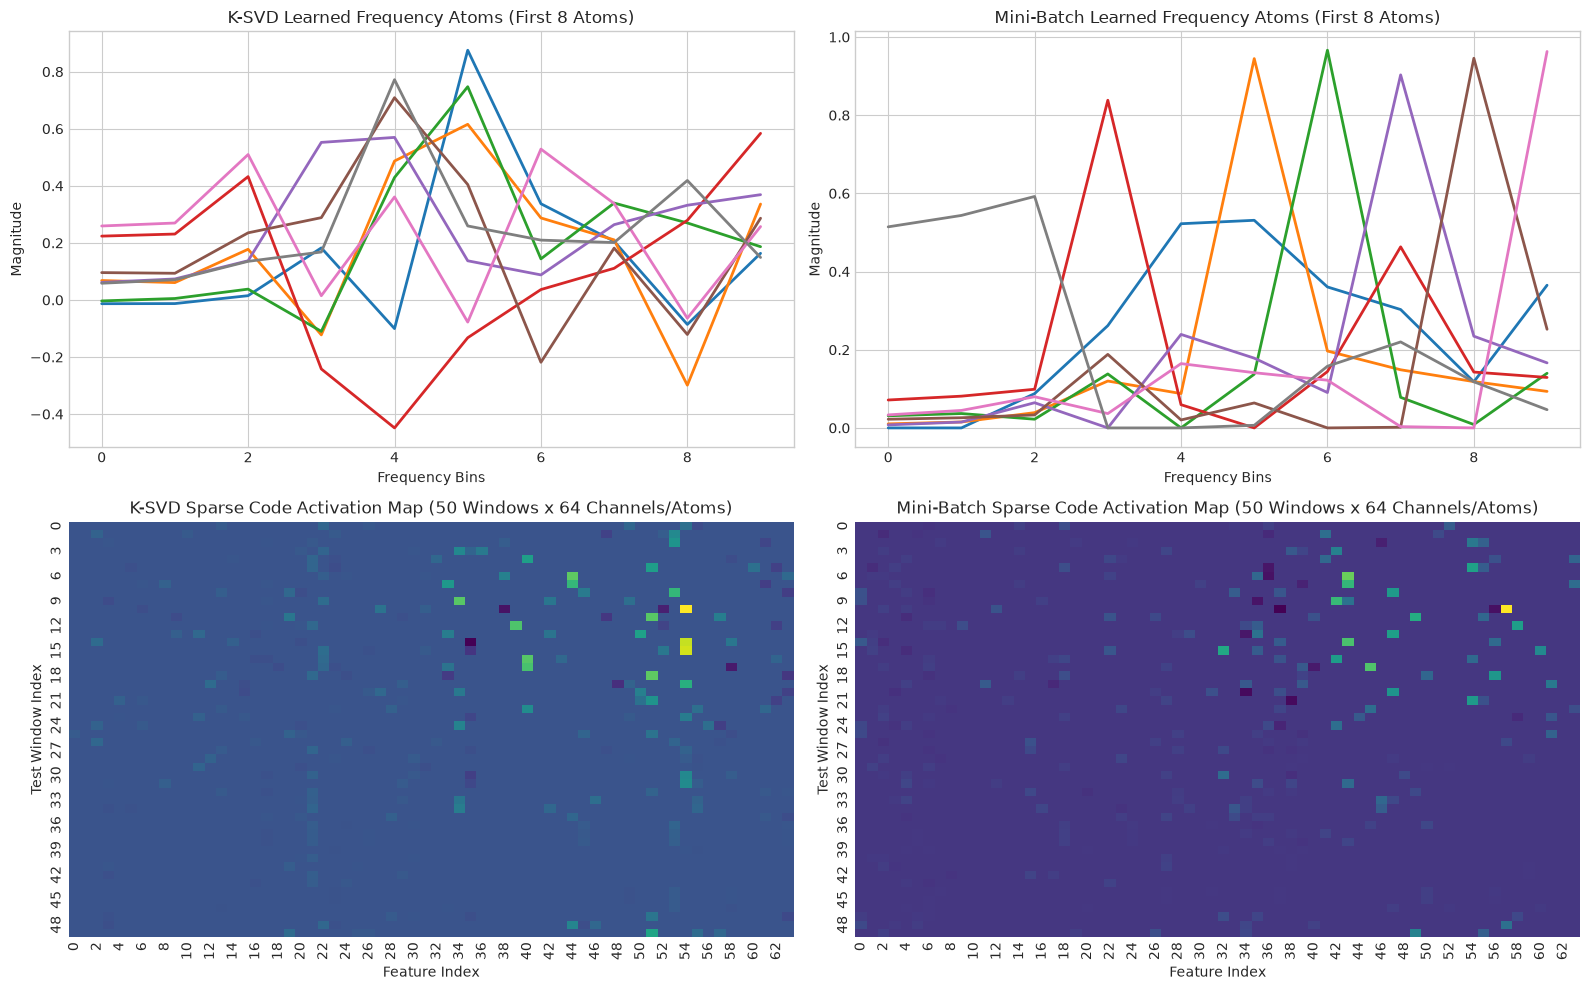

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot 1: K-SVD Learned Atoms
axes[0, 0].plot(ksvd_learner.dictionary_[:8].T, linewidth=2)
axes[0, 0].set_title("K-SVD Learned Frequency Atoms (First 8 Atoms)")
axes[0, 0].set_xlabel("Frequency Bins")
axes[0, 0].set_ylabel("Magnitude")

# Subplot 2: Mini-Batch Learned Atoms
axes[0, 1].plot(mb_learner.dictionary_[:8].T, linewidth=2)
axes[0, 1].set_title("Mini-Batch Learned Frequency Atoms (First 8 Atoms)")
axes[0, 1].set_xlabel("Frequency Bins")
axes[0, 1].set_ylabel("Magnitude")

# Subplot 3: K-SVD Sparse Code Activations Heatmap (First 50 test windows)
sns.heatmap(X_test_ksvd_sparse[:50, :64], ax=axes[1, 0], cmap='viridis', cbar=False)
axes[1, 0].set_title("K-SVD Sparse Code Activation Map (50 Windows x 64 Channels/Atoms)")
axes[1, 0].set_xlabel("Feature Index")
axes[1, 0].set_ylabel("Test Window Index")

# Subplot 4: Mini-Batch Sparse Code Activations Heatmap (First 50 test windows)
sns.heatmap(X_test_mb_sparse[:50, :64], ax=axes[1, 1], cmap='viridis', cbar=False)
axes[1, 1].set_title("Mini-Batch Sparse Code Activation Map (50 Windows x 64 Channels/Atoms)")
axes[1, 1].set_xlabel("Feature Index")
axes[1, 1].set_ylabel("Test Window Index")

plt.tight_layout()
plt.show()